<span style="color:green; font-size:26px; font-weight:bold;">MODELO 4: </span>

<span style="color:green; font-size:33px; font-weight:bold;">RANDOM FOREST CLASSIFIER</span>

________________________________________________________________________________________________________________________________


### Justificación   

El algoritmo Random Forest constituye una extensión de los árboles de decisión basada en la construcción de múltiples árboles entrenados sobre diferentes muestras aleatorias de los datos. La predicción final se obtiene mediante la agregación de las predicciones individuales de todos los árboles del bosque.

Este enfoque permite reducir el sobreajuste que suele presentar un árbol de decisión aislado, mejorando la capacidad de generalización del modelo. Además, Random Forest es especialmente adecuado para conjuntos de datos de tipo encuesta, donde pueden existir relaciones complejas entre las variables explicativas.

Por estos motivos, se incorpora al estudio con el objetivo de evaluar si la combinación de múltiples árboles es capaz de mejorar la capacidad predictiva obtenida mediante la Regresión Logística y el Árbol de Decisión.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
#Cargo nuevo dataset que utilizaré a a partir de ahora para trabajar con modelos de clasificación

df_mod_clas = pd.read_csv('../1_Data/processed_clas.csv')
df_mod_clas.head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub,Bienestar_alto
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6,1
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2,1
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3,1
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4,1
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5,1


In [3]:
# Variables predictoras
X = df_mod_clas.drop(
    columns=['Terr_hist', 'Sexo', 'Edad_interv', 'Lugar_nacim', 'Nacionalidad',
       'Nivel_estudios', 'Actividad', 'Tipo_hogar','Target_Satisfacc_Vida', 'Bienestar_alto']
)

# Variable objetivo
y = df_mod_clas['Bienestar_alto']

In [4]:
#separo en test y train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10,
    stratify=y
)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (5284, 10)
Dimensiones de y: (5284,)


In [5]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Bienestar_alto
1    0.536787
0    0.463213
Name: proportion, dtype: float64

Test:
Bienestar_alto
1    0.536424
0    0.463576
Name: proportion, dtype: float64


Es recomendable mantener el mismo criterio para todos los modelos de clasificación. El escalador se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Creo y entreno el modelo

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=10
)

rf.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
#Hago las predicciones

y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf

array([0, 1, 1, ..., 1, 1, 0], shape=(1057,))

In [11]:
#Metricas: 

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.810
Precision: 0.808
Recall   : 0.847
F1-score : 0.827


La métricas de evaluación empeoran sensiblemente frente a las obtenidas en la regresión lineal.
La accuracy es de 0,728 pierde 9 puntos porcentuales frente a la regresión logística. El recall es de 0,72, lo que significa que identifica únicamente el 72,3% de las personas de bienestar alto frente al 84% de la regresión logística. El F1-score baja en 0,09 puntos.

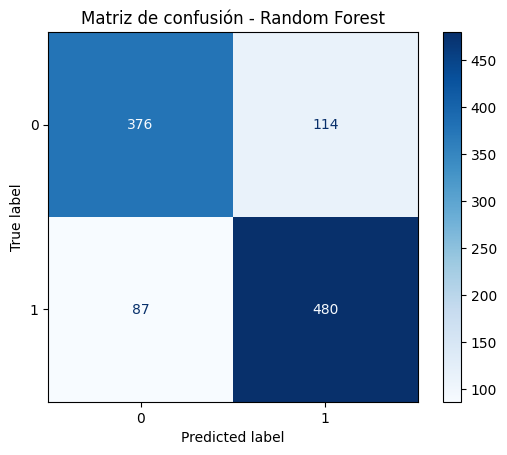

In [ ]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Blues'
)

plt.title('Matriz de confusión - Random Forest')
plt.show()

La matriz de confusión refuerza aún más la conclusión de que el Decision Tree no está funcionando tan bien como la Regresión Logística. Los falsos negativos aumentan en un 72%, caída que se refleja en el peor resultado arrojado por el recall (0,72%). Los falsos positivos también empeoran, lo que provoca la caídsa de la precision (0,758 frente a 0,819).

In [13]:
#Importancia de las variables:

importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
})

importancias_rf.sort_values(
    by='Importancia',
    ascending=False
)

,Variable,Importancia
0,Satisf_relac_pers,0.245729
1,Sentido_propia_vida,0.172163
2,Satisf_econom_domest,0.094677
5,Satisf_tiempo_disp,0.082191
4,Satisf_vivienda,0.081462
3,Valor_Estado_animo,0.078197
9,Confianza_poderes_pub,0.075126
8,Confianza_personas,0.069729
6,Satisf_viv_y_entorno,0.053954
7,Salud_percibida,0.046772


Ante los peores resultados obtenidos por el árbol de decisión, hago una prueba reduciendo ka profundidad máxima del árbol a 4 niveles, con el objetivo de valorar si se está produciendo un overittinf que dificulta una adecuada generalización: 

In [43]:
#Vuelvo a entrenar el modelo limitando la profundidad a 4 niveles
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=10
)

dt.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",10
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [44]:
#Hago las predicciones

y_pred_dt = dt.predict(X_test_scaled)
y_pred_dt

array([0, 1, 1, ..., 1, 0, 0], shape=(1057,))

In [45]:
#Metricas: 

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Accuracy : 0.806
Precision: 0.816
Recall   : 0.824
F1-score : 0.820


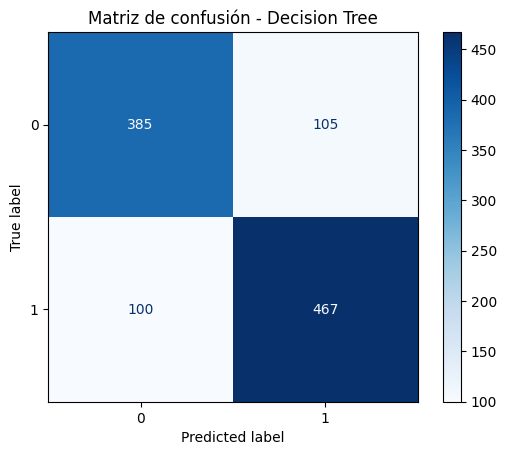

In [46]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap='Blues'
)

plt.title('Matriz de confusión - Decision Tree')
plt.show()


Tras una primera prueba con un árbol de decisión sin restricciones, se observó un rendimiento significativamente inferior al obtenido mediante Regresión Logística. Esto indicaba un posible problema de sobreajuste (overfitting), por lo que se decidió limitar la profundidad máxima del árbol a 4 niveles (`max_depth = 4`).

Con esta configuración, el modelo obtuvo los siguientes resultados:

* Accuracy: 0,806
* Precision: 0,816
* Recall: 0,824
* F1-score: 0,820

Los resultados muestran una mejora muy notable respecto al árbol sin restricciones y un rendimiento muy próximo al alcanzado por la Regresión Logística. El modelo clasifica correctamente aproximadamente el 80,6% de los casos, manteniendo además un equilibrio adecuado entre precisión y capacidad de detección de los individuos con altos niveles de bienestar.

La matriz de confusión confirma este comportamiento. El modelo identifica correctamente 385 individuos pertenecientes al grupo de menor bienestar (verdaderos negativos) y 467 individuos pertenecientes al grupo de bienestar elevado (verdaderos positivos). Los errores de clasificación se distribuyen entre 105 falsos positivos y 100 falsos negativos, lo que indica un comportamiento equilibrado entre ambas clases y ausencia de sesgos significativos hacia alguno de los grupos.

La comparación con la Regresión Logística muestra que las diferencias son reducidas. Aunque el árbol de decisión obtiene valores ligeramente inferiores en Accuracy, Recall y F1-score, el rendimiento global es muy similar. Esto sugiere que la relación entre las variables explicativas y la variable objetivo puede representarse adecuadamente tanto mediante relaciones lineales como mediante reglas de decisión jerárquicas.

En consecuencia, el modelo de Árbol de Decisión constituye una alternativa válida para la clasificación del bienestar elevado. No obstante, la Regresión Logística mantiene una ligera ventaja en términos de capacidad predictiva, además de ofrecer una mayor simplicidad e interpretabilidad de los resultados.

No es que uno sea mucho mejor que el otro, sino que la poda del árbol ha permitido eliminar prácticamente todo el sobreajuste inicial y obtener un modelo competitivo.
